In [1]:
import os 
import numpy as np
import pandas as pd
import scanpy as sc
import sys
from glob import glob
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

import warnings 
warnings.filterwarnings('ignore') 

import seaborn as sns
from anndata import AnnData
from scipy.stats import pearsonr, spearmanr, wilcoxon

sys.path.append("./../../STAN")
import stan

sys.path.append("./../../STAN/notebooks/")
import auxiliary_plot as auxpl
#figsize = auxpl.figsize
#fontsize = auxpl.fontsize

In [2]:
sample_list = ["GSM6506110_SP1", "GSM6506111_SP2", "GSM6506112_SP3", "GSM6506113_SP4", 
               "GSM6506114_SP5", "GSM6506115_SP6", "GSM6506116_SP7", "GSM6506117_SP8"]
adatas_raw = dict() # input of STAN
adatas_stan = dict() # output of SPAN
for sample in sample_list:
    adatas_raw[sample] = sc.read_h5ad("./../data/st_qc/{}.h5ad".format(sample))
    adatas_stan[sample] = sc.read_h5ad("./results/st_span/{}.h5ad".format(sample))

In [3]:
# celltypes count > 30spots
cell_types_dict = {
    "GSM6506110_SP1": ['Tumour_cells', 'Fibroblasts', "Endothelial_cells"],
    "GSM6506111_SP2": ['Tumour_cells', 'Fibroblasts',  'Macrophages', "B_Plasma_cells"],
    "GSM6506112_SP3": ['Tumour_cells', 'Fibroblasts', 'Myofibroblasts'],
    "GSM6506113_SP4": ['Tumour_cells', 'Fibroblasts'],
    "GSM6506114_SP5": ['Tumour_cells', 'Fibroblasts', 'Macrophages', "B_Plasma_cells"],
    "GSM6506115_SP6": ['Tumour_cells', 'Fibroblasts', 'Macrophages', "B_Plasma_cells", "Endothelial_cells"],
    "GSM6506116_SP7": ['Tumour_cells', 'Fibroblasts', "Endothelial_cells"],
    "GSM6506117_SP8": ['Tumour_cells', 'Fibroblasts', 'Myofibroblasts', "Endothelial_cells"]
}

In [4]:
for sample in sample_list:
    cellType_deconvolution = pd.read_csv("./../cellType_deconvolution/results/{}.csv".format(sample), index_col = 0)
    #print(cellType_deconvolution.shape)
    cellType_deconvolution.reset_index(inplace = True)
    cellType_deconvolution[['Sample', 'barcode']] = cellType_deconvolution['index'].str.split('_',  expand=True)
    cellType_deconvolution = cellType_deconvolution.drop("index", axis = 1)
    cellType_deconvolution.set_index("barcode", inplace = True)
    cellTypes_df = cellType_deconvolution.loc[adatas_raw[sample].obs.index, cell_types_dict[sample]] # cell_types_dict[sample]
    #print(cellTypes_df.shape)
    adatas_raw[sample].obsm["cellTypes"] = cellTypes_df
    adatas_stan[sample].obsm["cellTypes"] = cellTypes_df

In [5]:
cell_type_annotations = pd.read_csv("./../cellType_deconvolution/results/rctd_cell_type_annotations.csv" )
cell_type_annotations[["patient", "barcode"]] = cell_type_annotations["index"].str.split("_", expand = True)

print(cell_type_annotations.shape)
#cell_type_annotations.head(3)

for sample in sample_list:
    adatas_stan[sample].obs["barcode"] = adatas_stan[sample].obs.index
    temp = adatas_stan[sample].obs.merge(cell_type_annotations[cell_type_annotations["patient"]==sample[12:14]][["cell_type_annotations",
                            "barcode"]], on = "barcode", how = "left" )
    temp.set_index("barcode", inplace = True)
    print(np.unique(adatas_stan[sample].obs.index == temp.index, return_counts=True))

    adatas_stan[sample].obs["cell_type_annotations"] = temp["cell_type_annotations"].values

(20109, 4)
(array([ True]), array([2930]))
(array([ True]), array([1932]))
(array([ True]), array([1501]))
(array([ True]), array([3002]))
(array([ True]), array([2106]))
(array([ True]), array([1792]))
(array([ True]), array([3593]))
(array([ True]), array([3174]))


In [6]:
# Extract the inferred Pathway activity matrix
adatas_pathways = dict()
for sample in sample_list:
    adata_stan = adatas_stan[sample]
    adatas_pathway = AnnData(
        X = adata_stan.obsm['tfa_stan'],
        obs = adata_stan.obs,
        obsm = {name: obj for (name, obj) in adata_stan.obsm.items() if "tf" not in name},
        layers = {name: obj for (name, obj) in adata_stan.obsm.items() if "tf" in name})
    adatas_pathway.uns = adata_stan.uns
    adatas_pathways[sample] = adatas_pathway

## Clustering based on pathway Activity

In [7]:
adatas_pathways_scaled = dict()
def pathway_clustering(adata_pathway, n_neighbor = 50, res = 0.3):
    adata = adata_pathway.copy()
    sc.pp.scale(adata)
    
    sc.tl.pca(adata, n_comps=10)
    sc.pp.neighbors(adata, n_neighbors= n_neighbor, use_rep="X_pca")
    sc.tl.leiden(adata, resolution= res)

    sc.tl.umap(adata)
    sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
    return adata
    

#### Patient 1

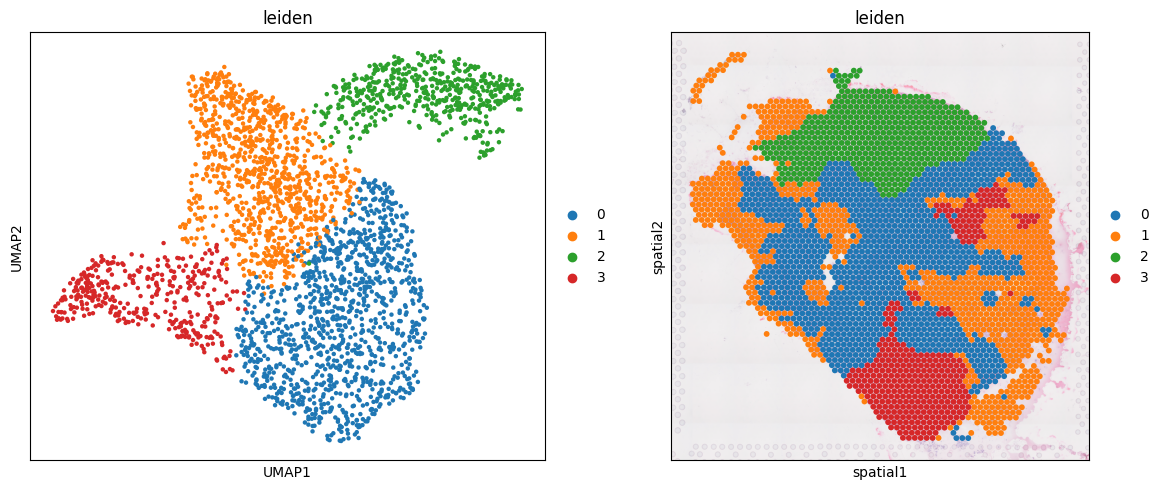

In [9]:
sample = sample_list[0]
adatas_pathways_scaled[sample] = pathway_clustering(adatas_pathways[sample], n_neighbor= 100, res = 0.3)
adatas_pathways_scaled[sample].obs[['sample', 'leiden', 'cell_type_annotations']].to_csv("./results/cluster_labels/{}.csv".format(sample))

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
sc.pl.umap(adatas_pathways_scaled[sample], color=["leiden"], ax=axs[0], show = False)
sc.pl.spatial(adatas_pathways_scaled[sample], color=["leiden"], size=1.5, alpha_img= 0.5, ax=axs[1], show = False)
plt.tight_layout()
plt.savefig("./results/{}_clustering.png".format(sample), dpi=300, bbox_inches='tight')
plt.show()

In [10]:
print(sample, "\n", pd.crosstab(index=adatas_pathways_scaled[sample].obs['cell_type_annotations'], 
                                columns=adatas_pathways_scaled[sample].obs['leiden']))

GSM6506110_SP1 
 leiden                    0    1    2    3
cell_type_annotations                     
B_Plasma_cells            0    0    0    1
Endothelial_cells         1    8    0   26
Fibroblasts              84   39    2  271
Macrophages               0    0    1    2
Mesothelial_cells         0    0    0    5
Myofibroblasts            0    0    0   25
Tumour_cells           1031  893  495   46


In [11]:
cluster2_specific_pathways = ['KRAS_SIGNALING_UP', 'APOPTOSIS',  'COMPLEMENT',  
                           'REACTIVE_OXYGEN_SPECIES_PATHWAY', 'INTERFERON_ALPHA_RESPONSE', 'IL2_STAT5_SIGNALING', 
                           'IL6_JAK_STAT3_SIGNALING', 'KRAS_SIGNALING_DN', 'CHOLESTEROL_HOMEOSTASIS', 'PROTEIN_SECRETION', 'ANDROGEN_RESPONSE']

cluster0_specific_pathways = [ 'ANGIOGENESIS', 'INFLAMMATORY_RESPONSE',
                           'WNT_BETA_CATENIN_SIGNALING', 'APICAL_SURFACE', "BILE_ACID_METABOLISM" ]

cluster1_specific_pathways = [ 'G2M_CHECKPOINT', 'MYC_TARGETS_V1', 'MYC_TARGETS_V2','E2F_TARGETS','DNA_REPAIR', 'MITOTIC_SPINDLE',
                           'OXIDATIVE_PHOSPHORYLATION',  'UNFOLDED_PROTEIN_RESPONSE', 
                             "PANCREAS_BETA_CELLS",  'PI3K_AKT_MTOR_SIGNALING', 'PEROXISOME', 'ESTROGEN_RESPONSE_LATE', 
                           'GLYCOLYSIS', 'MTORC1_SIGNALING', 'NOTCH_SIGNALING',  'HEME_METABOLISM',
                           'HYPOXIA',   'P53_PATHWAY',
                            'UV_RESPONSE_UP',
                           'SPERMATOGENESIS', 'HEDGEHOG_SIGNALING']

cluster3_specific_pathways = ['EPITHELIAL_MESENCHYMAL_TRANSITION', 'MYOGENESIS', 'COAGULATION', 'ESTROGEN_RESPONSE_EARLY', 'TGF_BETA_SIGNALING', 
                           'XENOBIOTIC_METABOLISM', 'INTERFERON_GAMMA_RESPONSE',  'ALLOGRAFT_REJECTION', 
                           'ADIPOGENESIS', "APICAL_JUNCTION", "FATTY_ACID_METABOLISM", 'TNFA_SIGNALING_VIA_NFKB','UV_RESPONSE_DN']
arranged_pathways = cluster2_specific_pathways+cluster3_specific_pathways+cluster1_specific_pathways+cluster0_specific_pathways
len(arranged_pathways)

50

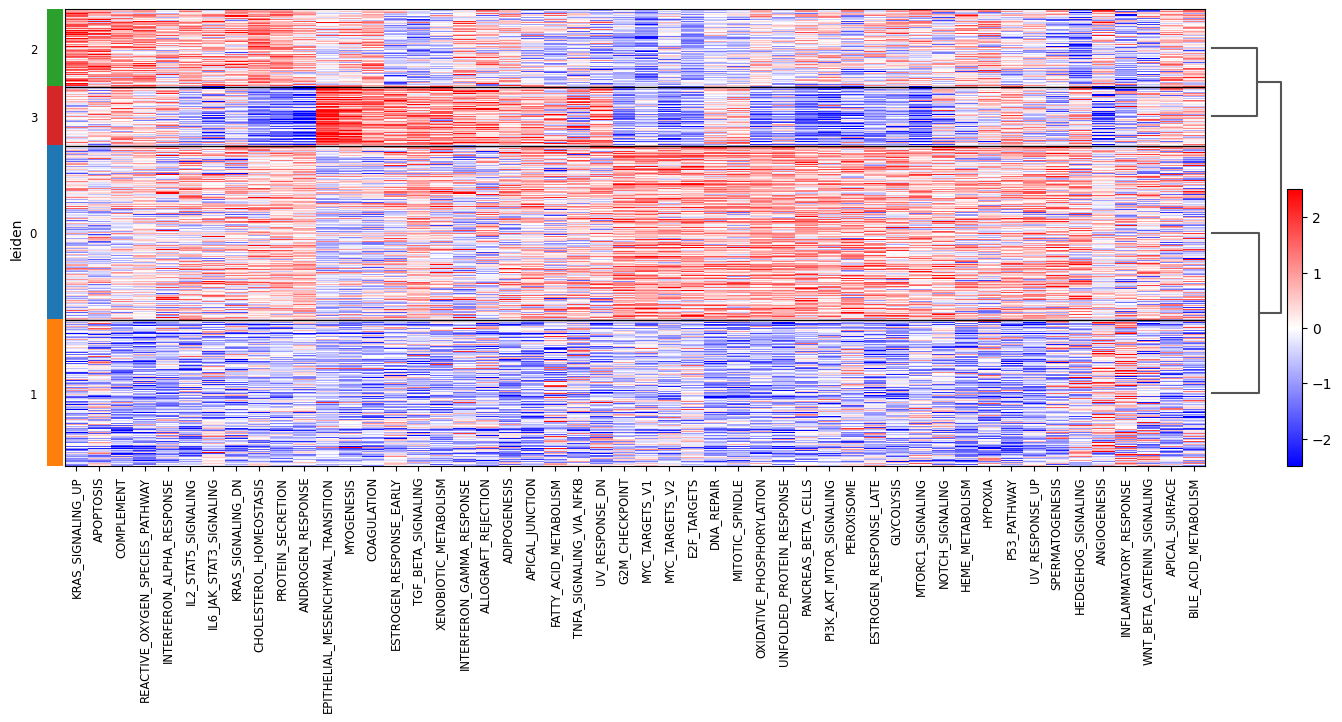

In [12]:
sc.pl.rank_genes_groups_heatmap(adatas_pathways_scaled[sample],  
                                var_names= arranged_pathways, 
                                groupby="leiden", cmap= "bwr", 
                                vcenter = 0, vmax= 2.5, vmin = -2.5, show = False)
plt.savefig("./results/{}_heatmap.png".format(sample), dpi=300, bbox_inches='tight')

#### Patient 2

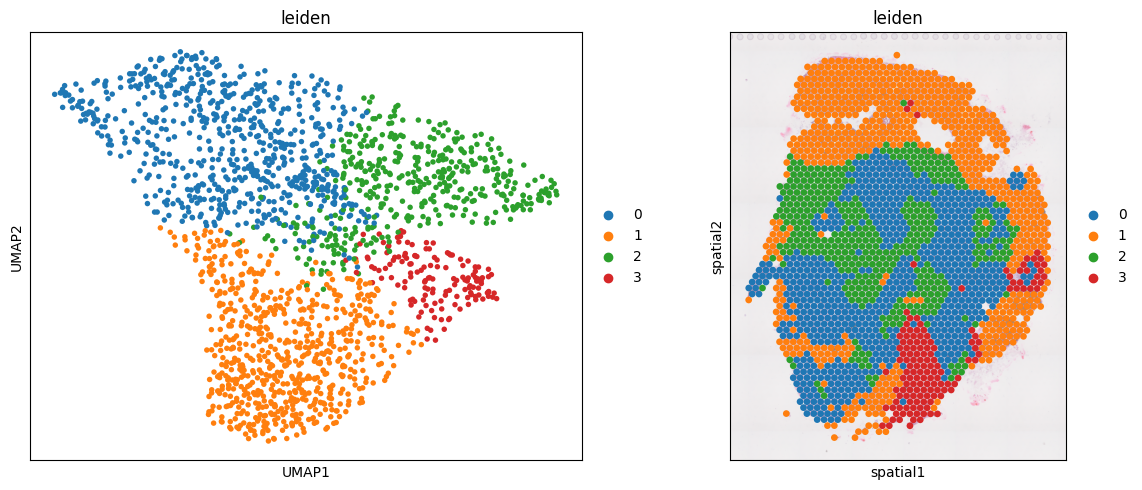

In [13]:
sample = sample_list[1]
adatas_pathways_scaled[sample] = pathway_clustering(adatas_pathways[sample], n_neighbor= 100, res = 0.3)
adatas_pathways_scaled[sample].obs[['sample', 'leiden', 'cell_type_annotations']].to_csv("./results/cluster_labels/{}.csv".format(sample))

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
sc.pl.umap(adatas_pathways_scaled[sample], color=["leiden"], ax=axs[0], show = False)
sc.pl.spatial(adatas_pathways_scaled[sample], color=["leiden"], size=1.5, alpha_img= 0.5, ax=axs[1], show = False)
plt.tight_layout()
plt.savefig("./results/{}_clustering.png".format(sample), dpi=300, bbox_inches='tight')
plt.show()

In [14]:
print(sample, "\n", pd.crosstab(index=adatas_pathways_scaled[sample].obs['cell_type_annotations'], 
                                columns=adatas_pathways_scaled[sample].obs['leiden']))

GSM6506111_SP2 
 leiden                   0    1    2    3
cell_type_annotations                    
B_Plasma_cells         108  193   34    9
Endothelial_cells        7    6    5    2
Fibroblasts             58   74  266   18
Macrophages             48   55   12  108
Mesothelial_cells        0    2    0    0
T_cells                  1    6    0    3
Tumour_cells           464  345  107    1


In [15]:
cluster2_specific_pathways = ['EPITHELIAL_MESENCHYMAL_TRANSITION', 'UV_RESPONSE_DN', 'MYOGENESIS','ANGIOGENESIS']

cluster0_specific_pathways = [ 'OXIDATIVE_PHOSPHORYLATION', 'MITOTIC_SPINDLE', 'G2M_CHECKPOINT', 'MYC_TARGETS_V1',
                            'DNA_REPAIR', 'HEME_METABOLISM',
                           'UNFOLDED_PROTEIN_RESPONSE','KRAS_SIGNALING_DN','PROTEIN_SECRETION','APICAL_JUNCTION', 'P53_PATHWAY',
                           'ANDROGEN_RESPONSE', 'SPERMATOGENESIS',
                           'INTERFERON_ALPHA_RESPONSE', 'NOTCH_SIGNALING',
                           'CHOLESTEROL_HOMEOSTASIS', 'PI3K_AKT_MTOR_SIGNALING', 'IL2_STAT5_SIGNALING', 'UV_RESPONSE_UP',
                           'ESTROGEN_RESPONSE_LATE','GLYCOLYSIS', 'MTORC1_SIGNALING', 'PANCREAS_BETA_CELLS', 'HEDGEHOG_SIGNALING',
                           'TGF_BETA_SIGNALING', 'ESTROGEN_RESPONSE_EARLY', 'E2F_TARGETS', 'APICAL_SURFACE',
                           'IL6_JAK_STAT3_SIGNALING', 'APOPTOSIS', 'MYC_TARGETS_V2','INFLAMMATORY_RESPONSE','FATTY_ACID_METABOLISM',
                           'PEROXISOME',
                            'WNT_BETA_CATENIN_SIGNALING', ]

cluster1_specific_pathways = [  ]

cluster3_specific_pathways = ['HYPOXIA','COMPLEMENT', 'REACTIVE_OXYGEN_SPECIES_PATHWAY', 'ALLOGRAFT_REJECTION', 'KRAS_SIGNALING_UP', 'COAGULATION',
                           'XENOBIOTIC_METABOLISM', 'TNFA_SIGNALING_VIA_NFKB', 'INTERFERON_GAMMA_RESPONSE', 'ADIPOGENESIS','BILE_ACID_METABOLISM']
arranged_pathways = cluster0_specific_pathways+cluster2_specific_pathways+cluster1_specific_pathways+cluster3_specific_pathways
len(arranged_pathways)

50

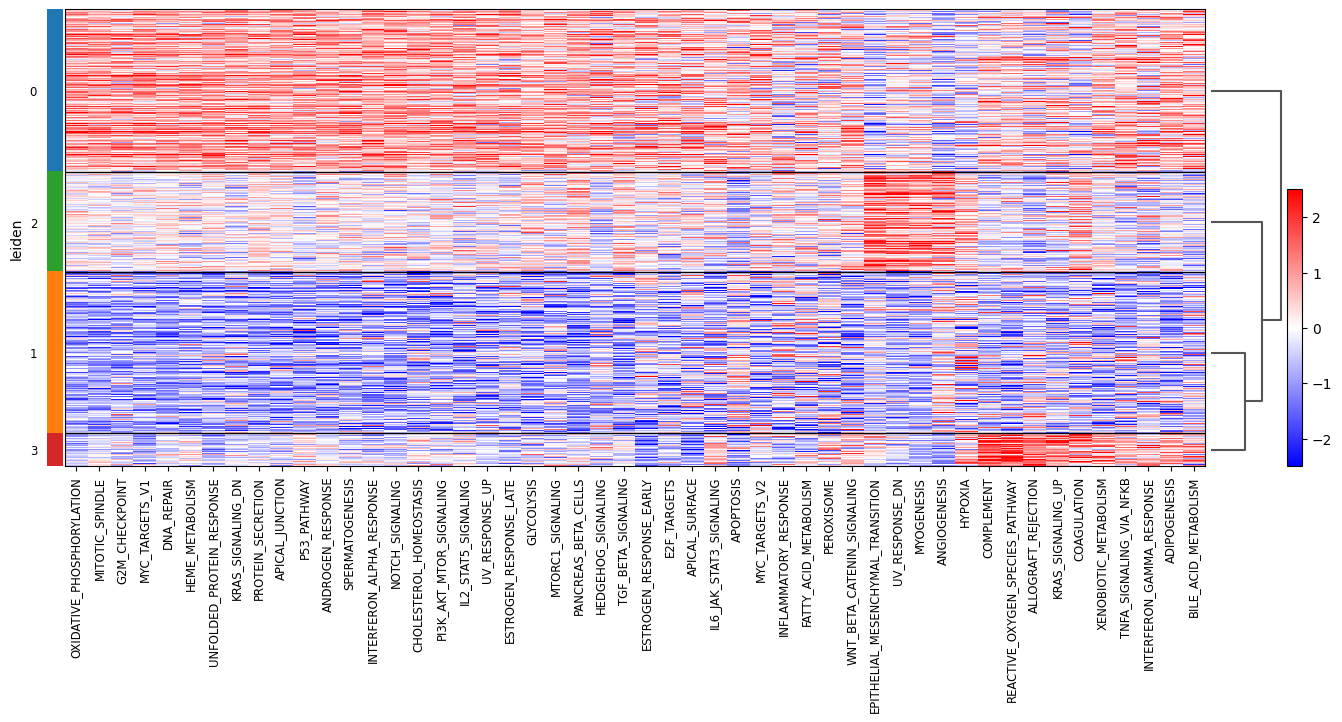

In [16]:
sc.pl.rank_genes_groups_heatmap(adatas_pathways_scaled[sample],  
                                var_names= arranged_pathways, 
                                groupby="leiden", cmap= "bwr", 
                                vcenter = 0, vmax= 2.5, vmin = -2.5, show = False)
plt.savefig("./results/{}_heatmap.png".format(sample), dpi=300, bbox_inches='tight')

#### Patient 3

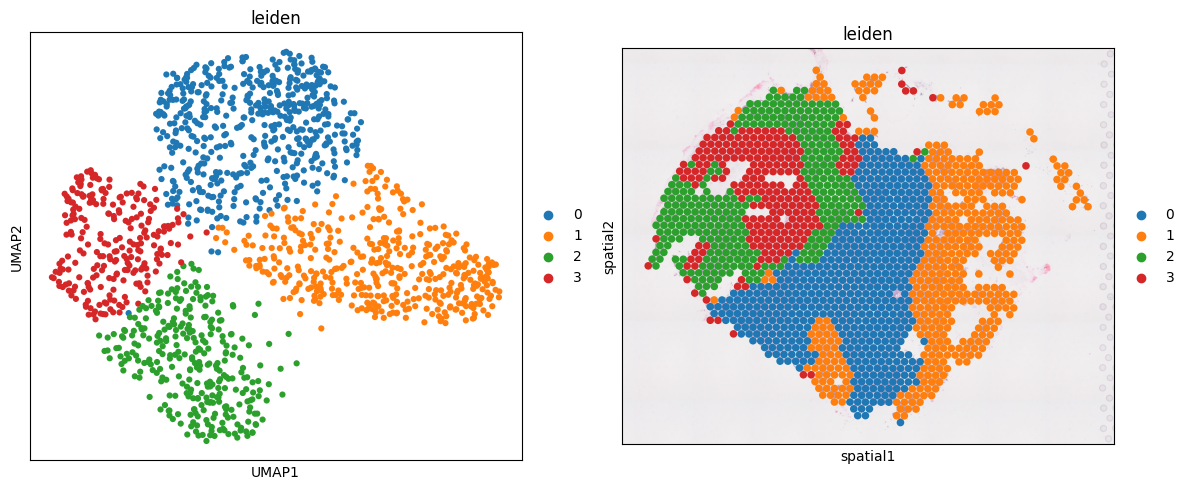

In [17]:
sample = sample_list[2]
adatas_pathways_scaled[sample] = pathway_clustering(adatas_pathways[sample], n_neighbor= 100, res = 0.3)
adatas_pathways_scaled[sample].obs[['sample', 'leiden', 'cell_type_annotations']].to_csv("./results/cluster_labels/{}.csv".format(sample))

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
sc.pl.umap(adatas_pathways_scaled[sample], color=["leiden"], ax=axs[0], show = False)
sc.pl.spatial(adatas_pathways_scaled[sample], color=["leiden"], size=1.5, alpha_img= 0.5, ax=axs[1], show = False)
plt.tight_layout()
plt.savefig("./results/{}_clustering.png".format(sample), dpi=300, bbox_inches='tight')
plt.show()

In [18]:
print(sample, "\n", pd.crosstab(index=adatas_pathways_scaled[sample].obs['cell_type_annotations'], 
                                columns=adatas_pathways_scaled[sample].obs['leiden']))

GSM6506112_SP3 
 leiden                   0    1    2    3
cell_type_annotations                    
B_Plasma_cells           2    3    0    0
Endothelial_cells        2    1    1    2
Fibroblasts            499   45   77  156
Mesothelial_cells        0    2    1    0
Myofibroblasts           5    0    2   38
Tumour_cells            11  387  228   39


In [19]:
cluster2_specific_pathways = ['P53_PATHWAY', 'TNFA_SIGNALING_VIA_NFKB','MYC_TARGETS_V1','ESTROGEN_RESPONSE_LATE','ESTROGEN_RESPONSE_EARLY',
                           'APOPTOSIS','ADIPOGENESIS','PANCREAS_BETA_CELLS','XENOBIOTIC_METABOLISM',
                           'FATTY_ACID_METABOLISM']

cluster0_specific_pathways = ['EPITHELIAL_MESENCHYMAL_TRANSITION','BILE_ACID_METABOLISM','WNT_BETA_CATENIN_SIGNALING','KRAS_SIGNALING_DN',
                           'COAGULATION','UV_RESPONSE_DN','TGF_BETA_SIGNALING','INFLAMMATORY_RESPONSE'  ]

cluster1_specific_pathways = [ 'INTERFERON_GAMMA_RESPONSE','MTORC1_SIGNALING','ANDROGEN_RESPONSE','KRAS_SIGNALING_UP','GLYCOLYSIS','E2F_TARGETS',
                           'PROTEIN_SECRETION','PEROXISOME', 'OXIDATIVE_PHOSPHORYLATION', 'CHOLESTEROL_HOMEOSTASIS', 
                          'INTERFERON_ALPHA_RESPONSE','G2M_CHECKPOINT','UNFOLDED_PROTEIN_RESPONSE','IL2_STAT5_SIGNALING','COMPLEMENT',
                           'ALLOGRAFT_REJECTION','SPERMATOGENESIS','HEME_METABOLISM','IL6_JAK_STAT3_SIGNALING','APICAL_JUNCTION',
                           'APICAL_SURFACE','PI3K_AKT_MTOR_SIGNALING','MITOTIC_SPINDLE','ANGIOGENESIS','NOTCH_SIGNALING',
                           'DNA_REPAIR', 'MYC_TARGETS_V2', 'HEDGEHOG_SIGNALING', 'REACTIVE_OXYGEN_SPECIES_PATHWAY','UV_RESPONSE_UP' ]

cluster3_specific_pathways = ['HYPOXIA', "MYOGENESIS"]
arranged_pathways = cluster1_specific_pathways+cluster0_specific_pathways+cluster2_specific_pathways+cluster3_specific_pathways
len(arranged_pathways)

50

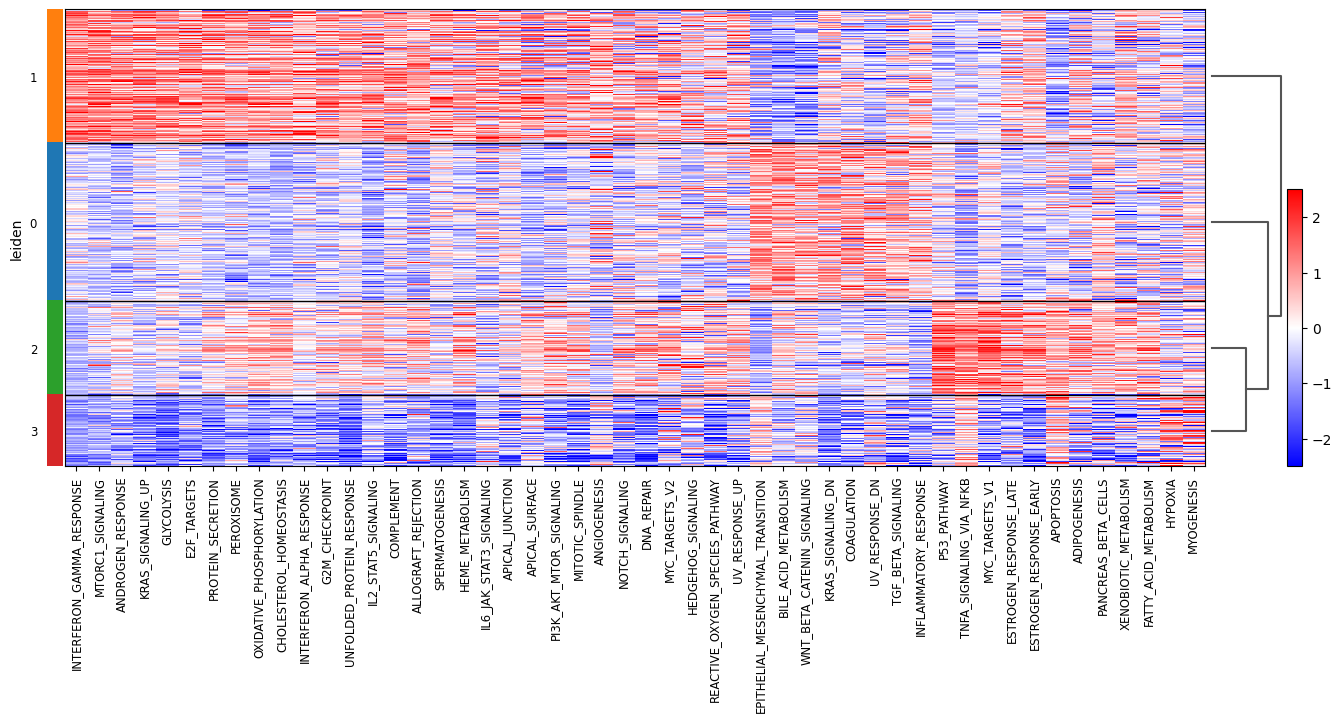

In [20]:
sc.pl.rank_genes_groups_heatmap(adatas_pathways_scaled[sample],  
                                var_names= arranged_pathways, 
                                groupby="leiden", cmap= "bwr", 
                                vcenter = 0, vmax= 2.5, vmin = -2.5, show = False)
plt.savefig("./results/{}_heatmap.png".format(sample), dpi=300, bbox_inches='tight')

#### Patient 4

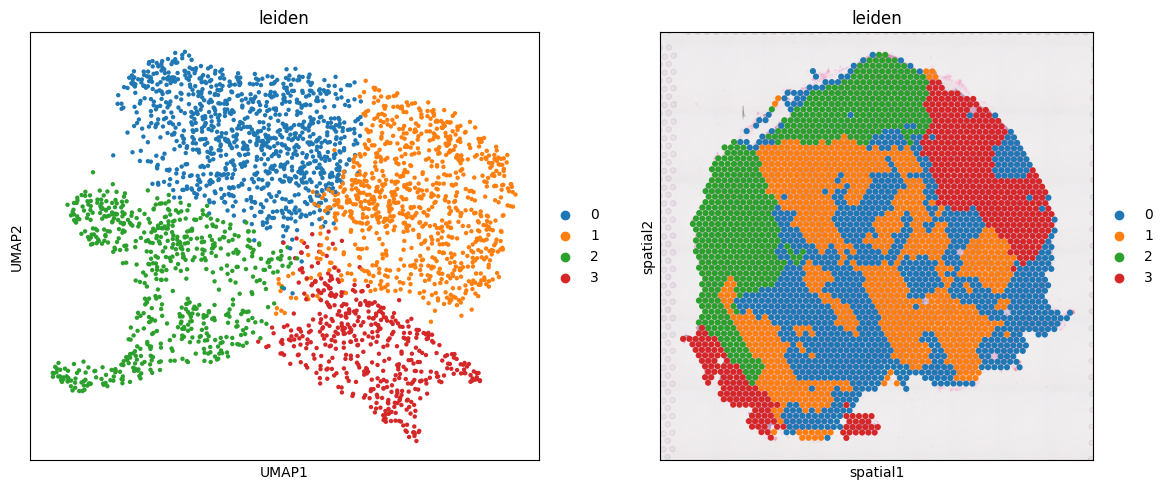

In [21]:
sample = sample_list[3]
adatas_pathways_scaled[sample] = pathway_clustering(adatas_pathways[sample], n_neighbor= 100, res = 0.25)
adatas_pathways_scaled[sample].obs[['sample', 'leiden', 'cell_type_annotations']].to_csv("./results/cluster_labels/{}.csv".format(sample))

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
sc.pl.umap(adatas_pathways_scaled[sample], color=["leiden"], ax=axs[0], show = False)
sc.pl.spatial(adatas_pathways_scaled[sample], color=["leiden"], size=1.5, alpha_img= 0.5, ax=axs[1], show = False)
plt.tight_layout()
plt.savefig("./results/{}_clustering.png".format(sample), dpi=300, bbox_inches='tight')
plt.show()

In [22]:
print(sample, "\n", pd.crosstab(index=adatas_pathways_scaled[sample].obs['cell_type_annotations'], 
                                columns=adatas_pathways_scaled[sample].obs['leiden']))

GSM6506113_SP4 
 leiden                    0    1    2    3
cell_type_annotations                     
Endothelial_cells         0    0    2    0
Fibroblasts               3    5  414    2
Tumour_cells           1010  888  211  467


In [23]:
cluster3_specific_pathways = ['CHOLESTEROL_HOMEOSTASIS','NOTCH_SIGNALING','SPERMATOGENESIS', 'HEME_METABOLISM','UNFOLDED_PROTEIN_RESPONSE',
                           'APOPTOSIS','GLYCOLYSIS','MTORC1_SIGNALING','APICAL_SURFACE','ADIPOGENESIS','REACTIVE_OXYGEN_SPECIES_PATHWAY', 
                           'UV_RESPONSE_UP','BILE_ACID_METABOLISM', 'TNFA_SIGNALING_VIA_NFKB' ]

cluster0_specific_pathways = [ ]

cluster1_specific_pathways = ['KRAS_SIGNALING_DN','KRAS_SIGNALING_UP', 'OXIDATIVE_PHOSPHORYLATION','IL2_STAT5_SIGNALING','PI3K_AKT_MTOR_SIGNALING',
                           'P53_PATHWAY','PROTEIN_SECRETION','DNA_REPAIR','MITOTIC_SPINDLE','G2M_CHECKPOINT','ANDROGEN_RESPONSE', 'MYC_TARGETS_V1',
                           'COMPLEMENT','E2F_TARGETS','ESTROGEN_RESPONSE_EARLY','ESTROGEN_RESPONSE_LATE','INTERFERON_ALPHA_RESPONSE',  
                           'PEROXISOME', 'XENOBIOTIC_METABOLISM', 'PANCREAS_BETA_CELLS','INFLAMMATORY_RESPONSE', 'MYC_TARGETS_V2', 
                           'HEDGEHOG_SIGNALING', 'INTERFERON_GAMMA_RESPONSE',  'APICAL_JUNCTION' ,'FATTY_ACID_METABOLISM', 'ALLOGRAFT_REJECTION',
                           'IL6_JAK_STAT3_SIGNALING', 'COAGULATION', 'ANGIOGENESIS']

cluster2_specific_pathways = ['EPITHELIAL_MESENCHYMAL_TRANSITION','UV_RESPONSE_DN','TGF_BETA_SIGNALING','HYPOXIA','MYOGENESIS',
                           'WNT_BETA_CATENIN_SIGNALING']

arranged_pathways = cluster2_specific_pathways+cluster3_specific_pathways+cluster0_specific_pathways+cluster1_specific_pathways
len(arranged_pathways)

50

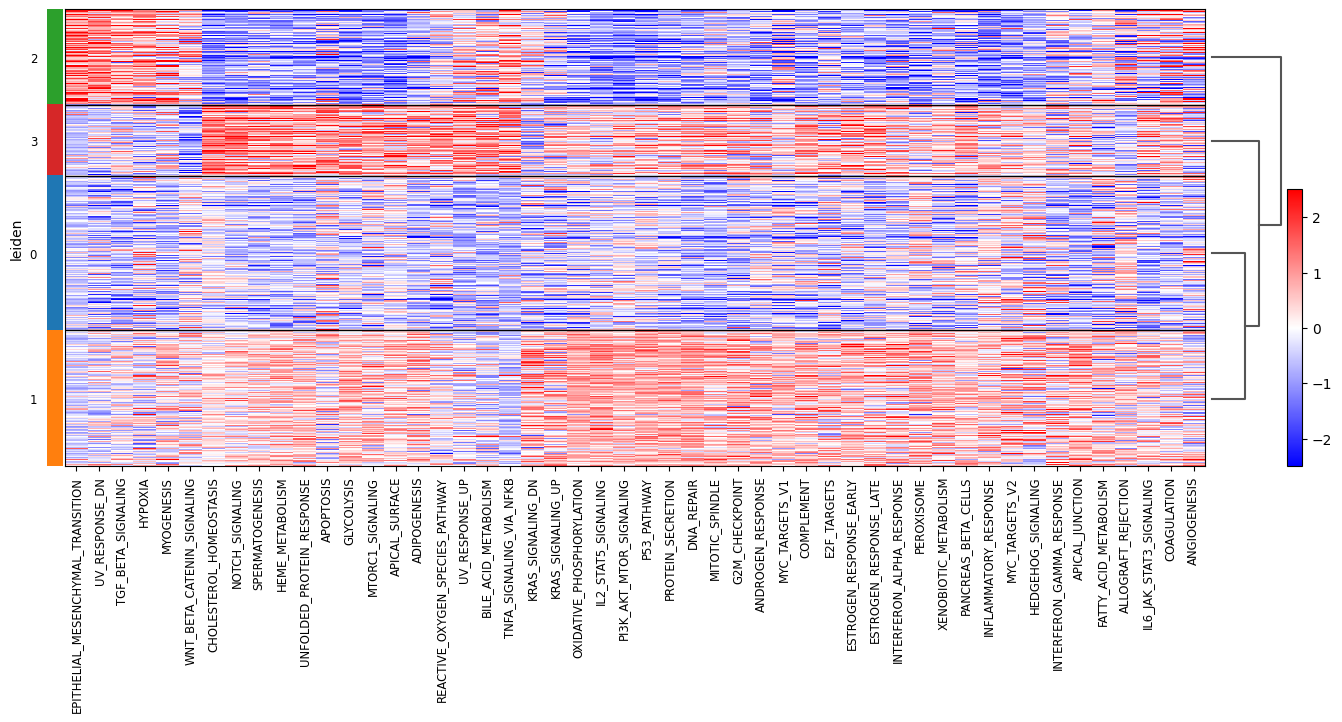

In [24]:
sc.pl.rank_genes_groups_heatmap(adatas_pathways_scaled[sample],  
                                var_names= arranged_pathways, 
                                groupby="leiden", cmap= "bwr", 
                                vcenter = 0, vmax= 2.5, vmin = -2.5, show = False)
plt.savefig("./results/{}_heatmap.png".format(sample), dpi=300, bbox_inches='tight')

#### Patient 5

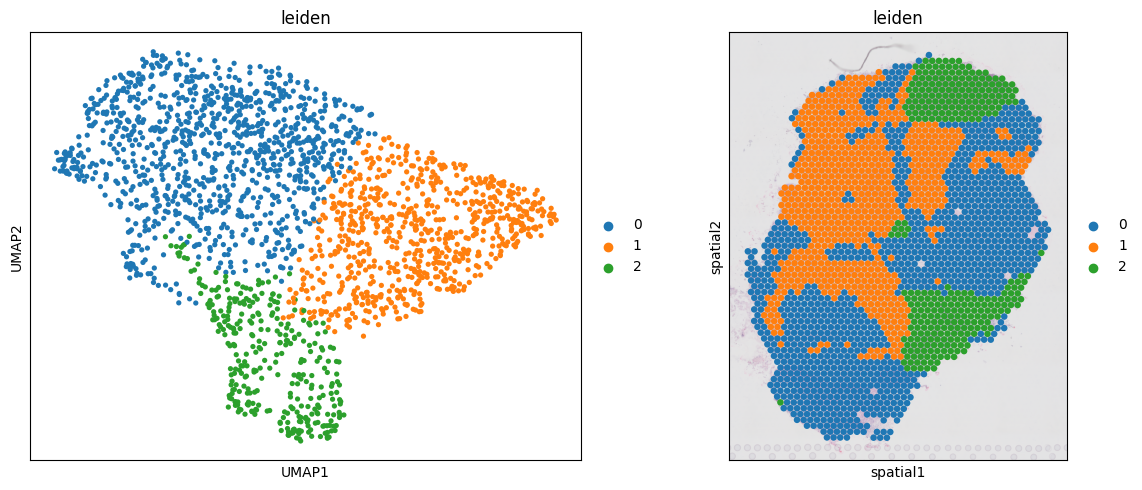

In [25]:
sample = sample_list[4]
adatas_pathways_scaled[sample] = pathway_clustering(adatas_pathways[sample], n_neighbor= 100, res = 0.3)
adatas_pathways_scaled[sample].obs[['sample','leiden', 'cell_type_annotations']].to_csv("./results/cluster_labels/{}.csv".format(sample))

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
sc.pl.umap(adatas_pathways_scaled[sample], color=["leiden"], ax=axs[0], show = False)
sc.pl.spatial(adatas_pathways_scaled[sample], color=["leiden"], size=1.5, alpha_img= 0.5, ax=axs[1], show = False)
plt.tight_layout()
plt.savefig("./results/{}_clustering.png".format(sample), dpi=300, bbox_inches='tight')
plt.show()

In [26]:
print(sample, "\n", pd.crosstab(index=adatas_pathways_scaled[sample].obs['cell_type_annotations'], 
                                columns=adatas_pathways_scaled[sample].obs['leiden']))

GSM6506114_SP5 
 leiden                   0    1    2
cell_type_annotations               
B_Plasma_cells          24    3   26
Endothelial_cells        8    0    6
Fibroblasts             13    0   27
Macrophages            978  714  141
Myofibroblasts          11    0    0
T_cells                  0    0    2
Tumour_cells            23    5  125


In [27]:
cluster0_specific_pathways = ['INFLAMMATORY_RESPONSE', 'FATTY_ACID_METABOLISM', "HYPOXIA" , 'ANGIOGENESIS', 'HEDGEHOG_SIGNALING',
                           'KRAS_SIGNALING_DN','MYC_TARGETS_V2','COAGULATION','WNT_BETA_CATENIN_SIGNALING']

cluster2_specific_pathways = ['APICAL_JUNCTION','INTERFERON_GAMMA_RESPONSE','MYC_TARGETS_V1','UNFOLDED_PROTEIN_RESPONSE','MYOGENESIS',
                           'TGF_BETA_SIGNALING', 'ESTROGEN_RESPONSE_EARLY', 'INTERFERON_ALPHA_RESPONSE', 'PEROXISOME', 'APICAL_SURFACE', 
                           'E2F_TARGETS','APOPTOSIS','UV_RESPONSE_DN','EPITHELIAL_MESENCHYMAL_TRANSITION']

cluster1_specific_pathways = ['REACTIVE_OXYGEN_SPECIES_PATHWAY','COMPLEMENT','XENOBIOTIC_METABOLISM','CHOLESTEROL_HOMEOSTASIS','KRAS_SIGNALING_UP',
                           'IL2_STAT5_SIGNALING','BILE_ACID_METABOLISM', 'TNFA_SIGNALING_VIA_NFKB',  'P53_PATHWAY', 'MTORC1_SIGNALING',
                           'IL6_JAK_STAT3_SIGNALING','NOTCH_SIGNALING', 'ALLOGRAFT_REJECTION', 'ADIPOGENESIS', 'UV_RESPONSE_UP', 
                           'ESTROGEN_RESPONSE_LATE','DNA_REPAIR',  'OXIDATIVE_PHOSPHORYLATION', 'GLYCOLYSIS',  
                           'MITOTIC_SPINDLE', 'G2M_CHECKPOINT', 'SPERMATOGENESIS','PI3K_AKT_MTOR_SIGNALING', 'PANCREAS_BETA_CELLS', 
                           'HEME_METABOLISM', 'PROTEIN_SECRETION', 'ANDROGEN_RESPONSE']

arranged_pathways = cluster2_specific_pathways+ cluster0_specific_pathways+cluster1_specific_pathways
len(arranged_pathways)

50

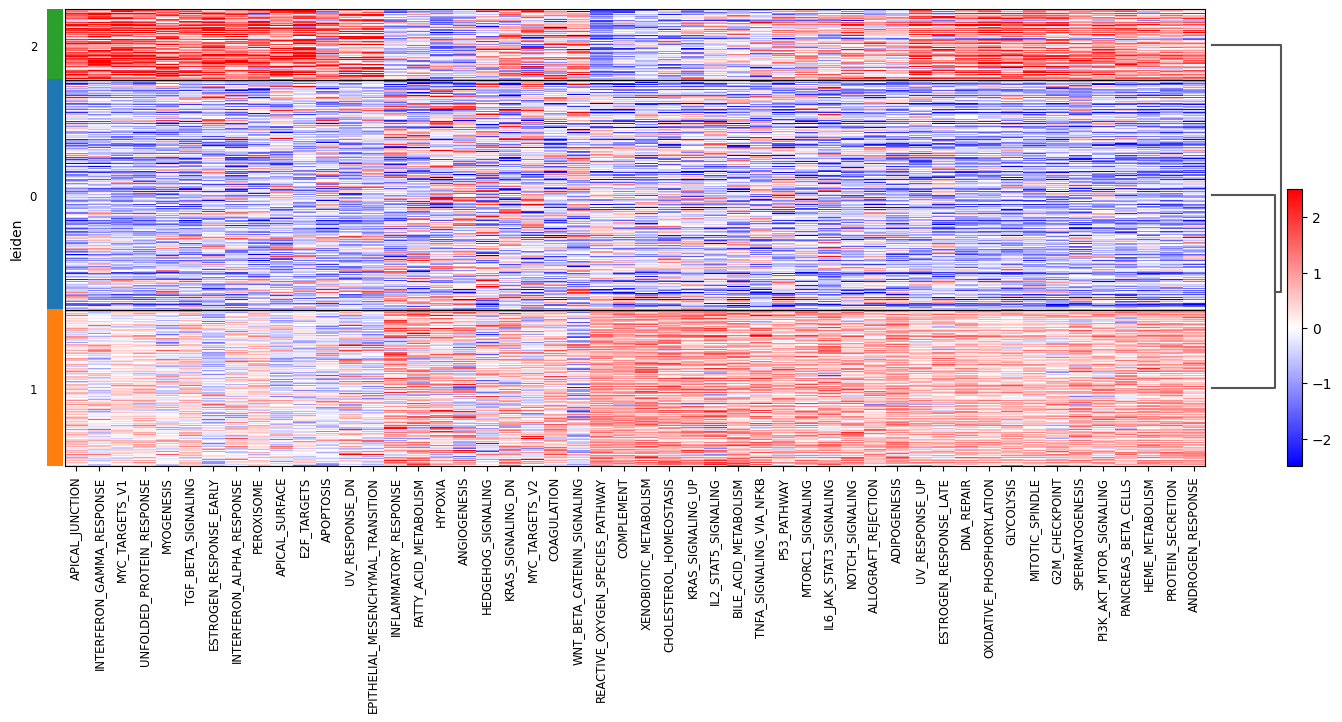

In [28]:
sc.pl.rank_genes_groups_heatmap(adatas_pathways_scaled[sample],  
                                var_names= arranged_pathways , 
                                groupby="leiden", cmap= "bwr", 
                                vcenter = 0, vmax= 2.5, vmin = -2.5, show = False)
plt.savefig("./results/{}_heatmap.png".format(sample), dpi=300, bbox_inches='tight')

#### Patient 6

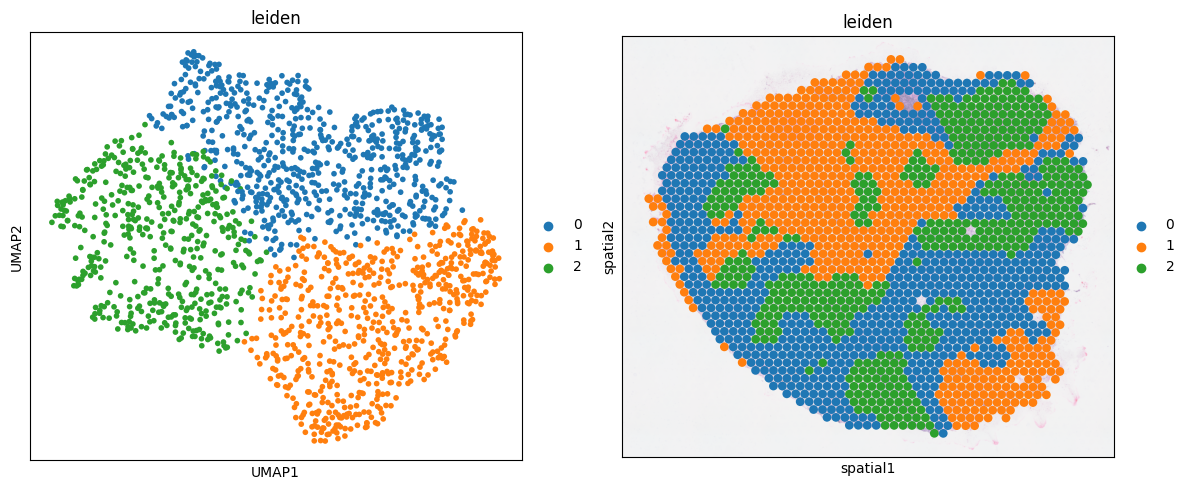

In [29]:
sample = sample_list[5]
adatas_pathways_scaled[sample] = pathway_clustering(adatas_pathways[sample], n_neighbor= 100, res = 0.3)
adatas_pathways_scaled[sample].obs[['sample','leiden', 'cell_type_annotations']].to_csv("./results/cluster_labels/{}.csv".format(sample))

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
sc.pl.umap(adatas_pathways_scaled[sample], color=["leiden"], ax=axs[0], show = False)
sc.pl.spatial(adatas_pathways_scaled[sample], color=["leiden"], size=1.5, alpha_img= 0.5, ax=axs[1], show = False)
plt.tight_layout()
plt.savefig("./results/{}_clustering.png".format(sample), dpi=300, bbox_inches='tight')
plt.show()

In [30]:
print(sample, "\n", pd.crosstab(index=adatas_pathways_scaled[sample].obs['cell_type_annotations'], 
                                columns=adatas_pathways_scaled[sample].obs['leiden']))

GSM6506115_SP6 
 leiden                   0    1    2
cell_type_annotations               
B_Plasma_cells          18   46   24
Endothelial_cells        3   24   16
Fibroblasts            651  256  286
Macrophages              6  263   32
Tumour_cells             0   36  131


In [31]:
cluster0_specific_pathways = ['EPITHELIAL_MESENCHYMAL_TRANSITION','COAGULATION','ANGIOGENESIS', 'MYOGENESIS', 'APOPTOSIS','HYPOXIA',
                           'UV_RESPONSE_DN','ESTROGEN_RESPONSE_EARLY', 'WNT_BETA_CATENIN_SIGNALING']

cluster2_specific_pathways = ['OXIDATIVE_PHOSPHORYLATION','PROTEIN_SECRETION','DNA_REPAIR','PI3K_AKT_MTOR_SIGNALING','G2M_CHECKPOINT',
                           'UNFOLDED_PROTEIN_RESPONSE','IL2_STAT5_SIGNALING','MITOTIC_SPINDLE','GLYCOLYSIS','NOTCH_SIGNALING',
                           'MYC_TARGETS_V1','HEME_METABOLISM','UV_RESPONSE_UP','SPERMATOGENESIS','MTORC1_SIGNALING','E2F_TARGETS',
                           'CHOLESTEROL_HOMEOSTASIS','KRAS_SIGNALING_UP','ANDROGEN_RESPONSE', 'ESTROGEN_RESPONSE_LATE','APICAL_SURFACE',
                           'PEROXISOME','PANCREAS_BETA_CELLS','XENOBIOTIC_METABOLISM','P53_PATHWAY','APICAL_JUNCTION','TGF_BETA_SIGNALING',
                           'ADIPOGENESIS','INTERFERON_ALPHA_RESPONSE','IL6_JAK_STAT3_SIGNALING','MYC_TARGETS_V2','KRAS_SIGNALING_DN', 
                           'HEDGEHOG_SIGNALING','FATTY_ACID_METABOLISM','INFLAMMATORY_RESPONSE','BILE_ACID_METABOLISM']

cluster1_specific_pathways = ['ALLOGRAFT_REJECTION','REACTIVE_OXYGEN_SPECIES_PATHWAY','TNFA_SIGNALING_VIA_NFKB','INTERFERON_GAMMA_RESPONSE','COMPLEMENT']

arranged_pathways =  cluster0_specific_pathways+cluster1_specific_pathways + cluster2_specific_pathways
len(arranged_pathways)

50

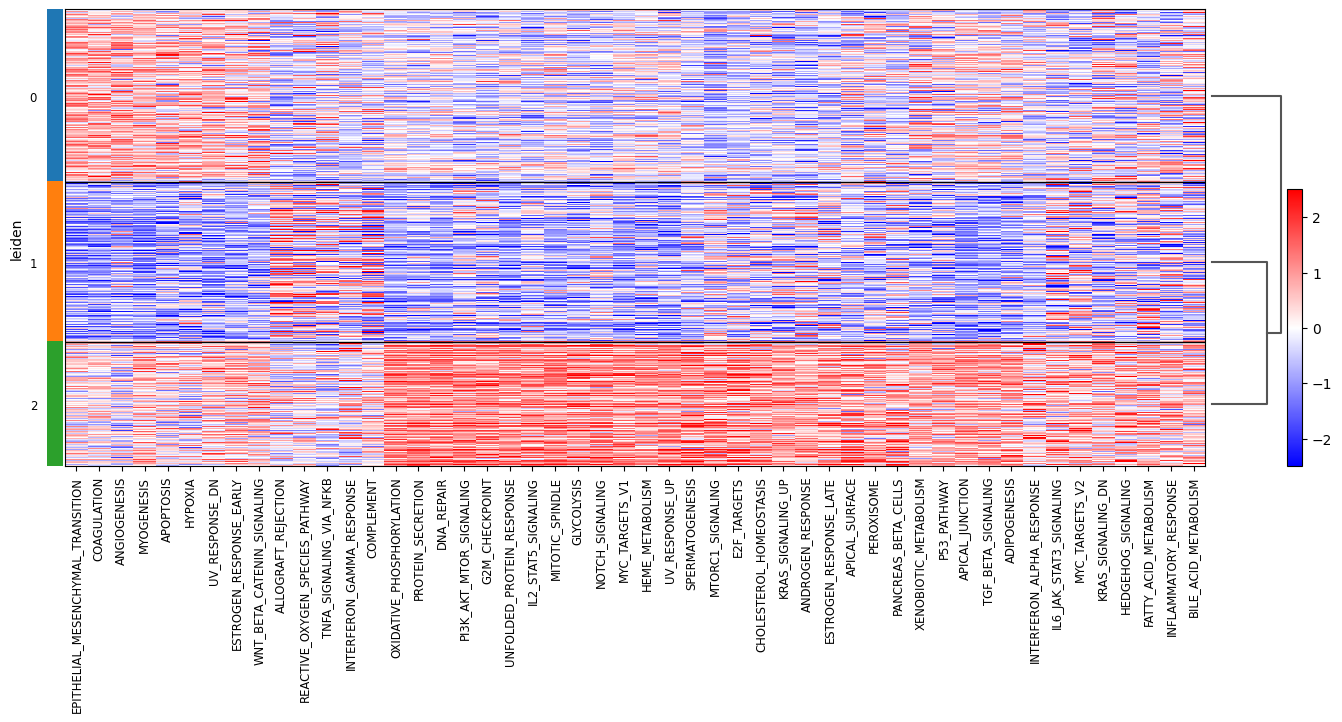

In [32]:
sc.pl.rank_genes_groups_heatmap(adatas_pathways_scaled[sample],  
                                var_names= arranged_pathways, 
                                groupby="leiden", cmap= "bwr", 
                                vcenter = 0, vmax= 2.5, vmin = -2.5, show = False)
plt.savefig("./results/{}_heatmap.png".format(sample), dpi=300, bbox_inches='tight')

#### Patient 7

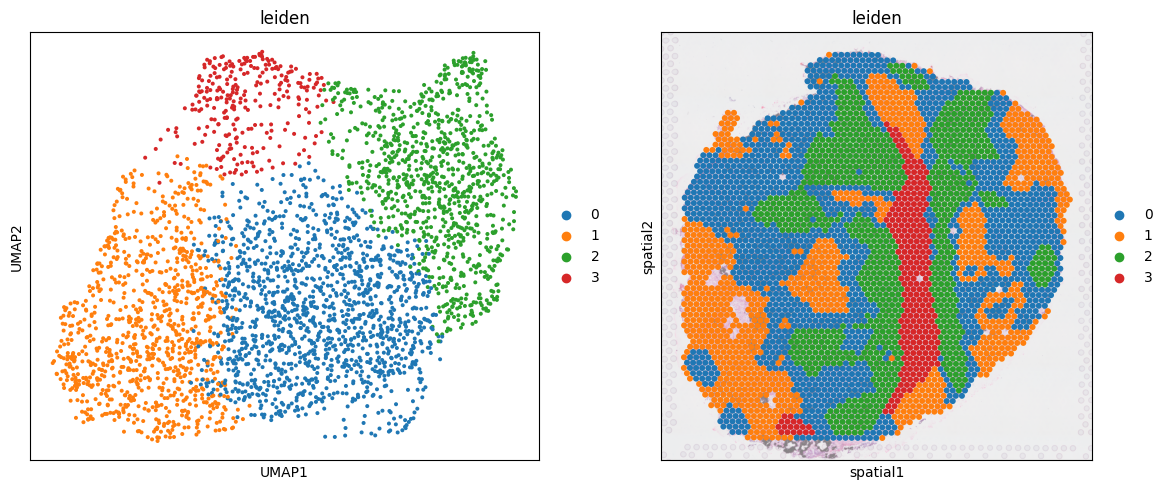

In [33]:
sample = sample_list[6]
adatas_pathways_scaled[sample] = pathway_clustering(adatas_pathways[sample], n_neighbor= 100, res = 0.25)
adatas_pathways_scaled[sample].obs[['sample', 'leiden', 'cell_type_annotations']].to_csv("./results/cluster_labels/{}.csv".format(sample))

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
sc.pl.umap(adatas_pathways_scaled[sample], color=["leiden"], ax=axs[0], show = False)
sc.pl.spatial(adatas_pathways_scaled[sample], color=["leiden"], size=1.5, alpha_img= 0.5, ax=axs[1], show = False)
plt.tight_layout()
plt.savefig("./results/{}_clustering.png".format(sample), dpi=300, bbox_inches='tight')
plt.show()

In [34]:
print(sample, "\n", pd.crosstab(index=adatas_pathways_scaled[sample].obs['cell_type_annotations'], 
                                columns=adatas_pathways_scaled[sample].obs['leiden']))

GSM6506116_SP7 
 leiden                    0    1    2    3
cell_type_annotations                     
Endothelial_cells         2    7    0   26
Fibroblasts               0   19    2   94
Mesothelial_cells         0    0    0    4
Myofibroblasts            0    3    2   10
Tumour_cells           1412  953  923  136


In [35]:
cluster2_specific_pathways = ['DNA_REPAIR','OXIDATIVE_PHOSPHORYLATION','HEME_METABOLISM','APICAL_JUNCTION','UNFOLDED_PROTEIN_RESPONSE',
                           'MITOTIC_SPINDLE','P53_PATHWAY','PROTEIN_SECRETION','INTERFERON_ALPHA_RESPONSE','PI3K_AKT_MTOR_SIGNALING',
                           'ESTROGEN_RESPONSE_LATE','G2M_CHECKPOINT','NOTCH_SIGNALING','MYC_TARGETS_V1','SPERMATOGENESIS','E2F_TARGETS',
                           'GLYCOLYSIS','KRAS_SIGNALING_UP','REACTIVE_OXYGEN_SPECIES_PATHWAY','IL2_STAT5_SIGNALING','ESTROGEN_RESPONSE_EARLY',
                           'MTORC1_SIGNALING','PANCREAS_BETA_CELLS','CHOLESTEROL_HOMEOSTASIS','FATTY_ACID_METABOLISM',
                           'HEDGEHOG_SIGNALING', 'ANDROGEN_RESPONSE','APICAL_SURFACE', 'PEROXISOME', 'TNFA_SIGNALING_VIA_NFKB']

cluster0_specific_pathways = [  ]

cluster1_specific_pathways = [ 'ANGIOGENESIS' ]

cluster3_specific_pathways = ['EPITHELIAL_MESENCHYMAL_TRANSITION','COAGULATION','MYOGENESIS','ADIPOGENESIS','COMPLEMENT','XENOBIOTIC_METABOLISM',
                           'HYPOXIA', 'INTERFERON_GAMMA_RESPONSE','KRAS_SIGNALING_DN', 'IL6_JAK_STAT3_SIGNALING','UV_RESPONSE_UP',
                           'TGF_BETA_SIGNALING','BILE_ACID_METABOLISM','ALLOGRAFT_REJECTION','APOPTOSIS','UV_RESPONSE_DN', 
                           'WNT_BETA_CATENIN_SIGNALING', 'INFLAMMATORY_RESPONSE', 'MYC_TARGETS_V2']

arranged_pathways = cluster0_specific_pathways+cluster2_specific_pathways+cluster1_specific_pathways+cluster3_specific_pathways
len(arranged_pathways)

50

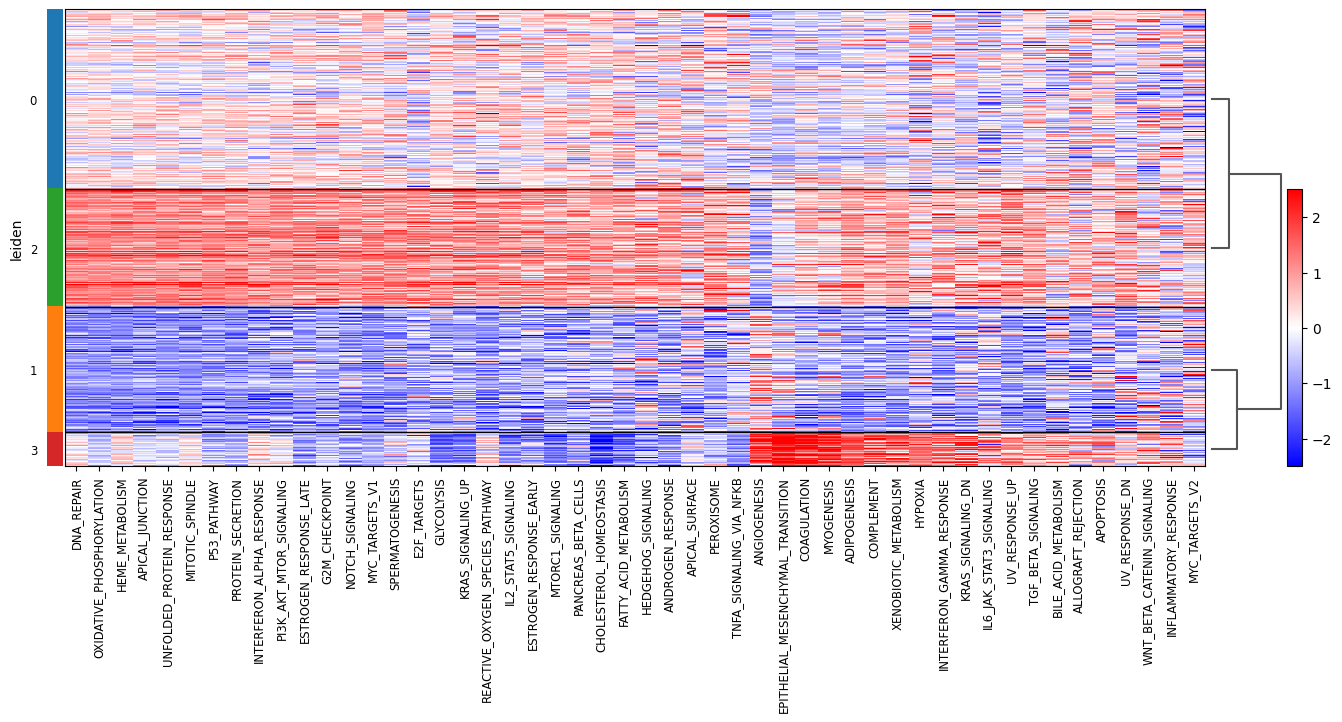

In [36]:
sc.pl.rank_genes_groups_heatmap(adatas_pathways_scaled[sample],  
                                var_names= arranged_pathways, 
                                groupby="leiden", cmap= "bwr", 
                                vcenter = 0, vmax= 2.5, vmin = -2.5, show = False)
plt.savefig("./results/{}_heatmap.png".format(sample), dpi=300, bbox_inches='tight')

#### Patient 8

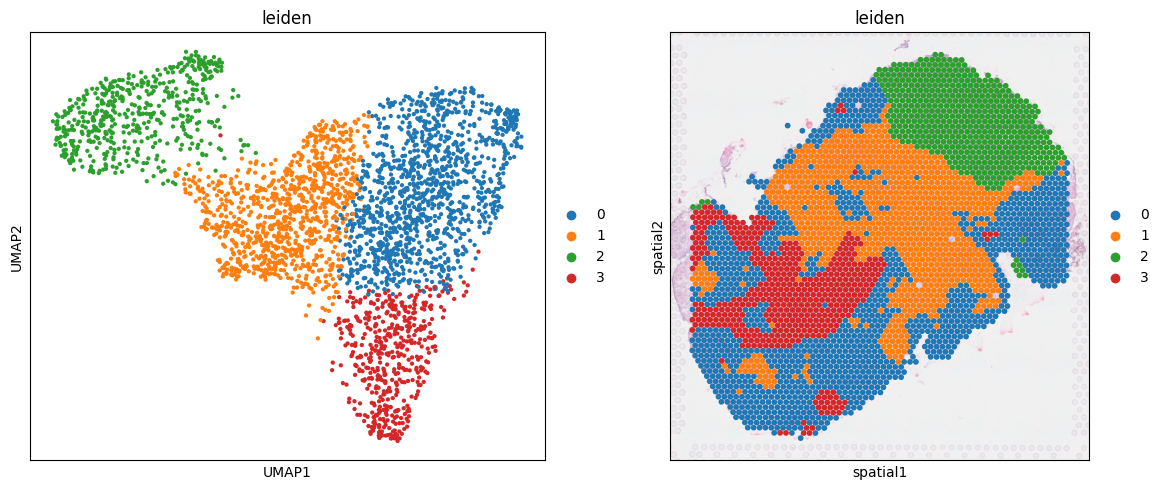

In [37]:
sample = sample_list[7]
adatas_pathways_scaled[sample] = pathway_clustering(adatas_pathways[sample], n_neighbor= 100, res = 0.3)
adatas_pathways_scaled[sample].obs[['sample','leiden', 'cell_type_annotations']].to_csv("./results/cluster_labels/{}.csv".format(sample))

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
sc.pl.umap(adatas_pathways_scaled[sample], color=["leiden"], ax=axs[0], show = False)
sc.pl.spatial(adatas_pathways_scaled[sample], color=["leiden"], size=1.5, alpha_img= 0.5, ax=axs[1], show = False)
plt.tight_layout()
plt.savefig("./results/{}_clustering.png".format(sample), dpi=300, bbox_inches='tight')
plt.show()

In [38]:
print(sample, "\n", pd.crosstab(index=adatas_pathways_scaled[sample].obs['cell_type_annotations'], 
                                columns=adatas_pathways_scaled[sample].obs['leiden']))

GSM6506117_SP8 
 leiden                   0    1    2    3
cell_type_annotations                    
Endothelial_cells      176  131    1   41
Fibroblasts            293   75    1   76
Macrophages              5    1    1    0
Mesothelial_cells        5    2    0    1
Myofibroblasts         547  684    0   29
Tumour_cells           200   50  524  331


In [39]:
cluster2_specific_pathways = ['GLYCOLYSIS','PROTEIN_SECRETION','MTORC1_SIGNALING','KRAS_SIGNALING_UP','ANGIOGENESIS','NOTCH_SIGNALING',
                           'CHOLESTEROL_HOMEOSTASIS','APICAL_SURFACE','G2M_CHECKPOINT','E2F_TARGETS','ANDROGEN_RESPONSE','INFLAMMATORY_RESPONSE',
                           'SPERMATOGENESIS','PI3K_AKT_MTOR_SIGNALING','ESTROGEN_RESPONSE_LATE','MYC_TARGETS_V1','OXIDATIVE_PHOSPHORYLATION', 
                           'PANCREAS_BETA_CELLS','REACTIVE_OXYGEN_SPECIES_PATHWAY', 'APICAL_JUNCTION','KRAS_SIGNALING_DN','HEME_METABOLISM',
                           'IL2_STAT5_SIGNALING', 'IL6_JAK_STAT3_SIGNALING', 'TGF_BETA_SIGNALING',  'MYC_TARGETS_V2',]

cluster0_specific_pathways = [ ]

cluster1_specific_pathways = [ 'EPITHELIAL_MESENCHYMAL_TRANSITION', 'MYOGENESIS','UV_RESPONSE_DN','WNT_BETA_CATENIN_SIGNALING', 
                           'INTERFERON_GAMMA_RESPONSE', 'HYPOXIA','ADIPOGENESIS', 'COAGULATION']

cluster3_specific_pathways = ['P53_PATHWAY', 'TNFA_SIGNALING_VIA_NFKB', 'INTERFERON_ALPHA_RESPONSE','ALLOGRAFT_REJECTION','APOPTOSIS',
                           'UV_RESPONSE_UP',  'XENOBIOTIC_METABOLISM', 'UNFOLDED_PROTEIN_RESPONSE','PEROXISOME', 'DNA_REPAIR', 
                           'ESTROGEN_RESPONSE_EARLY','MITOTIC_SPINDLE','BILE_ACID_METABOLISM','COMPLEMENT','FATTY_ACID_METABOLISM',
                           'HEDGEHOG_SIGNALING']

arranged_pathways = cluster0_specific_pathways+cluster1_specific_pathways+cluster2_specific_pathways+cluster3_specific_pathways
len(arranged_pathways)

50

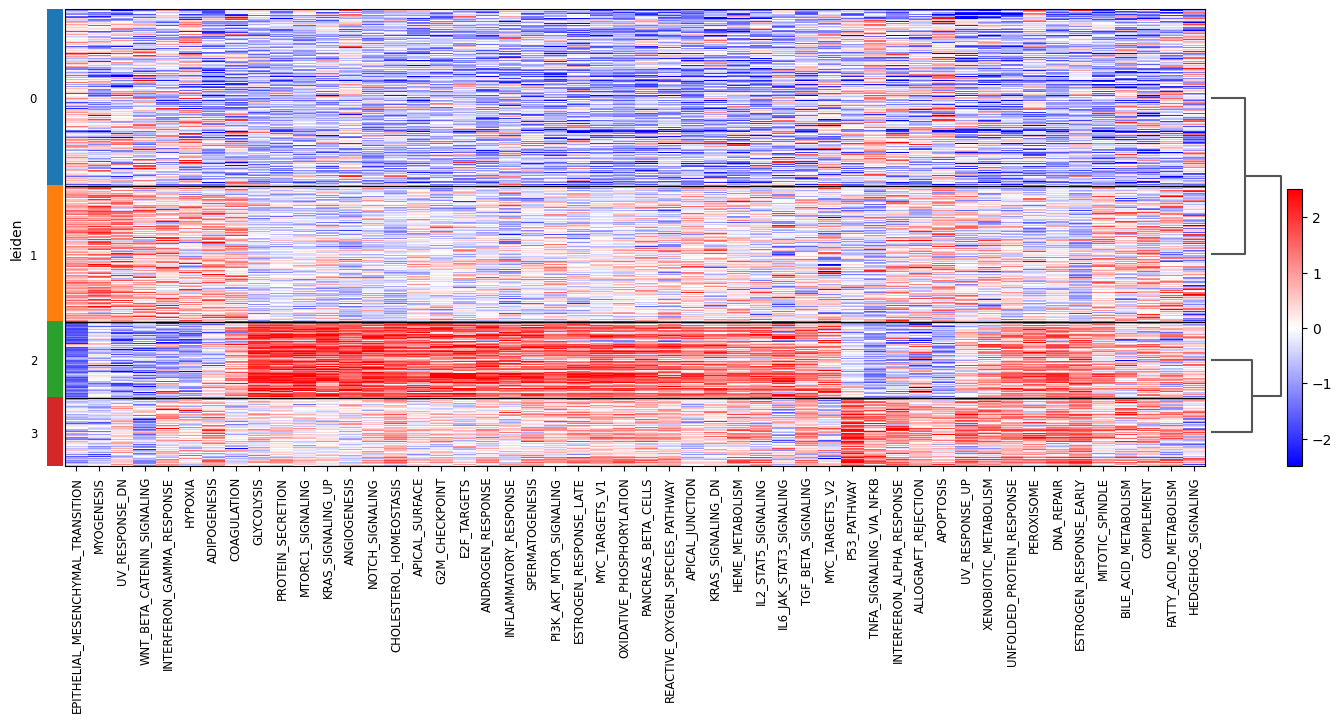

In [40]:
sc.pl.rank_genes_groups_heatmap(adatas_pathways_scaled[sample],  
                                var_names= arranged_pathways, 
                                groupby="leiden", cmap= "bwr", 
                                vcenter = 0, vmax= 2.5, vmin = -2.5, show = False)
plt.savefig("./results/{}_heatmap.png".format(sample), dpi=300, bbox_inches='tight')

## Spatial Plot

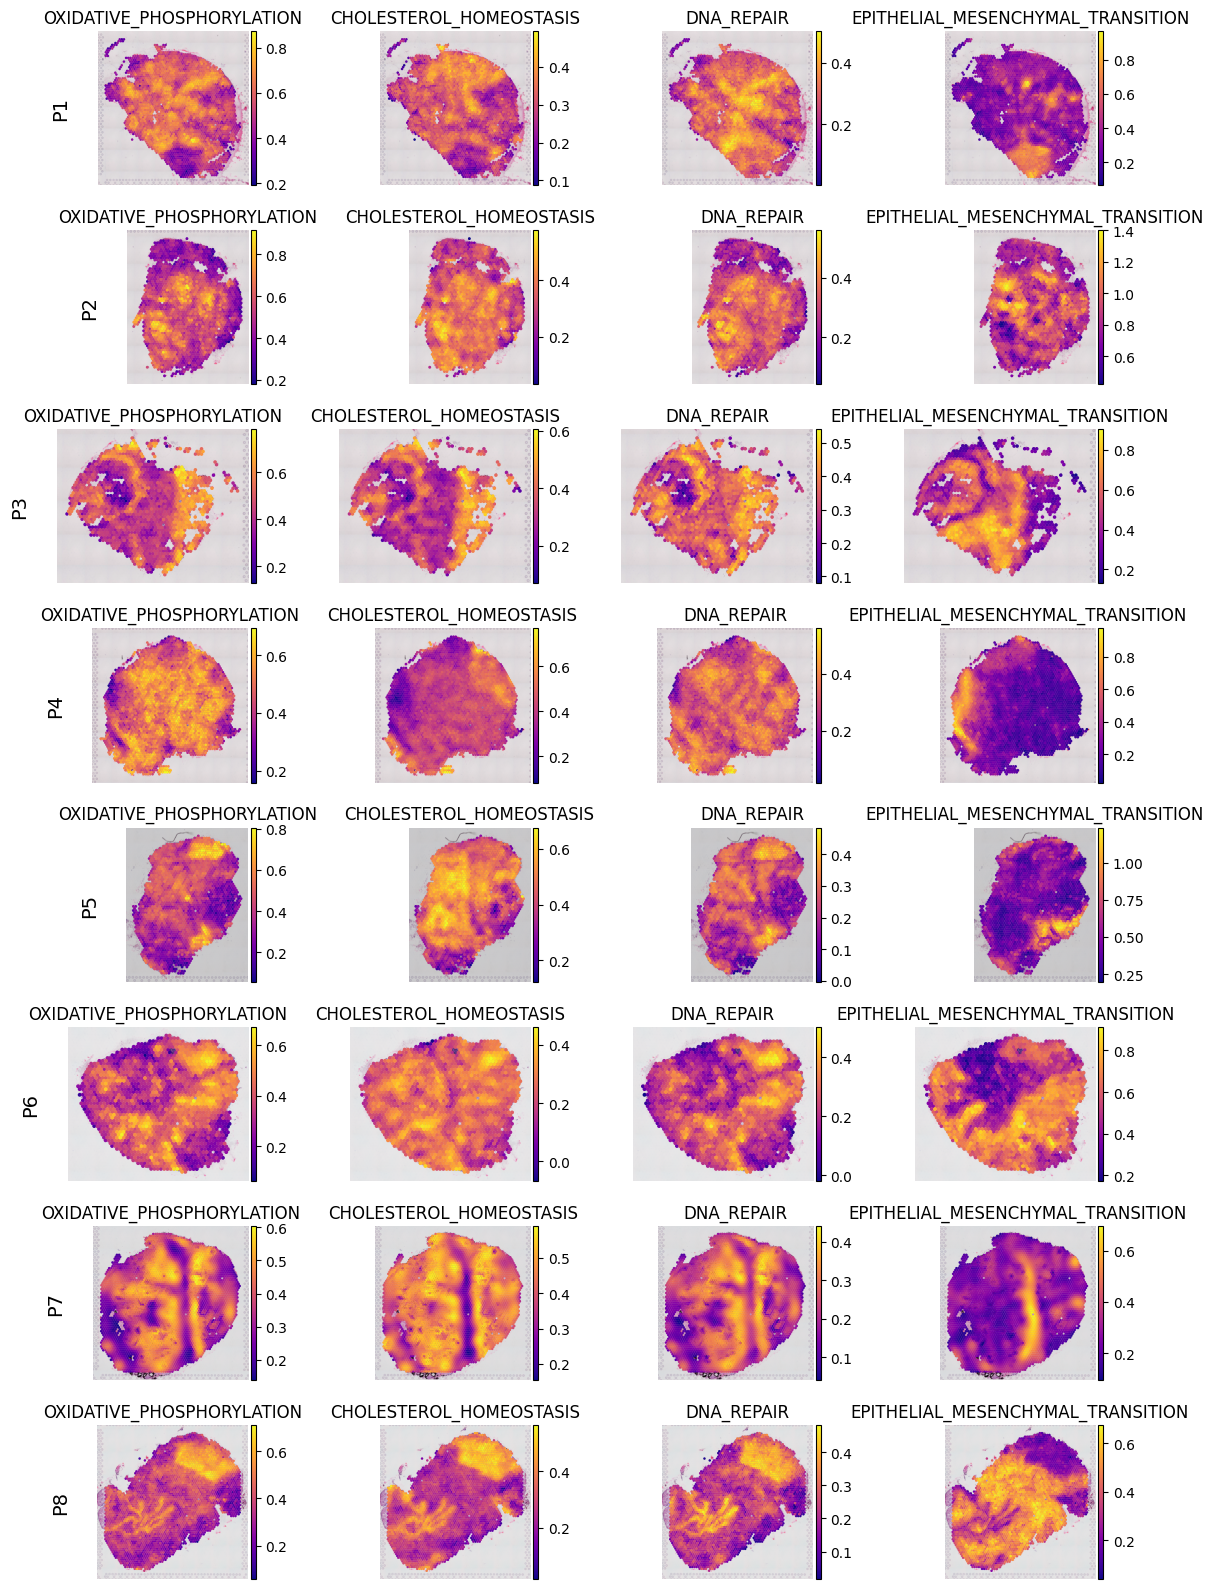

In [41]:
markers = ['OXIDATIVE_PHOSPHORYLATION', 'CHOLESTEROL_HOMEOSTASIS',"DNA_REPAIR", 'EPITHELIAL_MESENCHYMAL_TRANSITION']
# Make Axes
# Number of needed rows and columns (based on the row with the most columns)
nrow = len(sample_list)
ncol = len(markers)
fig, axs = plt.subplots(nrow, ncol, figsize=(3 * ncol, 2 * nrow))
# Plot expression for every marker on the corresponding Axes object
for row_idx, sample in enumerate(sample_list):
    col_idx = 0
    for m in markers:
        ax = axs[row_idx, col_idx]
        sc.pl.spatial(adatas_pathways[sample], color = m, size = 1.8, cmap = "plasma",
                      ax = ax, show = False, frameon = False)

        if col_idx == 0:
            # We disabled axis drawing in UMAP to have plots without background and border
            # so we need to re-enable axis to plot the ylabel
            ax.axis("on")
            ax.tick_params(
                top="off",
                bottom="off",
                left="off",
                right="off",
                labelleft="on",
                labelbottom="off",
            )
            ax.set_ylabel(sample[12:14] + "\n", rotation=90, fontsize=14)
            ax.set_xlabel("")
            ax.set(frame_on=False)
        col_idx += 1
        
# Alignment within the Figure
fig.tight_layout()
plt.savefig("./results/spatial_activity_plot.png", dpi=300, bbox_inches='tight')